In [4]:
!uv pip install ijson
import polars 
import ijson

Resolved 1 package in 69ms                                           
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)----     0 B/60.63 kB                      
⠙ Preparing packages... (0/1)---- 2.76 kB/60.63 kB                      
⠙ Preparing packages... (0/1)---- 5.51 kB/60.63 kB                      
⠙ Preparing packages... (0/1)---- 9.65 kB/60.63 kB                      
⠙ Preparing packages... (0/1)---- 13.78 kB/60.63 kB                     
⠙ Preparing packages... (0/1)---- 15.20 kB/60.63 kB                     
⠙ Preparing packages... (0/1)---- 23.39 kB/60.63 kB                     
⠙ Preparing packages... (0/1)---- 31.59 kB/60.63 kB                     
⠙ Preparing packages... (0/1)---- 47.97 kB/60.63 kB                     
Prepared 1 package in 18ms                                                   
Installed 1 package in 1ms                                  
 + ijson==3.5.0


In [ ]:
PATH = '/Users/piotrkaniewski/work/ec-kg-analysis/data/sop_no_filtered_kg/prm/integrated_kg_sop.json'
key = "CHEBI:52717|MONDO:0015758"
with open(PATH, 'rb') as f:
    for k, v in ijson.kvitems(f, ''):
        if k == key:
            objects = v
            break

# Flatten paths_metadata into an edge list (subject, predicate, object)
edge_rows = []
for meta in objects.get("paths_metadata", []):
    nodes = meta['nodes']
    edge_predicates = meta['edge_predicates']
    for i, preds in enumerate(edge_predicates):
        for predicate in preds:
            subject = nodes[i]
            object_ = nodes[i+1]
            edge_rows.append({'subject': subject, 'predicate': predicate, 'object': object_})

edges_df = polars.DataFrame(edge_rows)

# Load node category and name from the node file
nodes_path = '/Users/piotrkaniewski/work/ec-kg-analysis/data/integrated_kg/nodes.norm'
nodes_df = polars.read_parquet(nodes_path)[['id', 'category', 'name']]

# Left join to add subject category and name
edges_df = edges_df.join(
    nodes_df.rename({'id': 'subject', 'category': 'subject_category', 'name': 'subject_name'}),
    on='subject',
    how='left'
)

# Left join to add object category and name
edges_df = edges_df.join(
    nodes_df.rename({'id': 'object', 'category': 'object_category', 'name': 'object_name'}),
    on='object',
    how='left'
)

edges_df

subject,predicate,object,subject_category,subject_name,object_category,object_name,is_primekg,is_robokop,is_rtx
str,str,str,str,str,str,str,bool,bool,bool
"""CHEBI:52717""","""biolink:directly_physically_in…","""CHEBI:61076""","""biolink:Drug""","""Bortezomib""","""biolink:Drug""","""Belinostat""",false,false,false
"""CHEBI:52717""","""biolink:directly_physically_in…","""CHEBI:16962""","""biolink:Drug""","""Bortezomib""","""biolink:Drug""","""Cortisone acetate""",true,false,false
"""CHEBI:52717""","""biolink:affects""","""NCBIGene:1493""","""biolink:Drug""","""Bortezomib""","""biolink:Protein""","""CTLA4 protein, human""",false,true,false
"""CHEBI:232810""","""biolink:treats_or_applied_or_s…","""MONDO:0015758""","""biolink:Drug""","""Brigatinib""","""biolink:Disease""","""Primary cutaneous t-cell lymph…",false,false,false
"""NCBIGene:1029""","""biolink:genetically_associated…","""MONDO:0015758""","""biolink:Protein""","""CDKN2A protein, human""","""biolink:Disease""","""Primary cutaneous t-cell lymph…",false,false,false
…,…,…,…,…,…,…,…,…,…
"""CHEBI:52717""","""biolink:interacts_with""","""CHEBI:85990""","""biolink:Drug""","""Bortezomib""","""biolink:Drug""","""Panobinostat""",false,false,false
"""CHEBI:52717""","""biolink:interacts_with""","""CHEBI:6888""","""biolink:Drug""","""Bortezomib""","""biolink:Drug""","""Methylprednisolone""",false,false,false
"""MONDO:0015760""","""biolink:superclass_of""","""MONDO:0015758""","""biolink:Disease""","""T-cell non-hodgkin lymphoma""","""biolink:Disease""","""Primary cutaneous t-cell lymph…",false,false,false


In [58]:
pl.read_parquet(rtxkg2_edges_path)[["subject", "predicate", "object"]]

FileNotFoundError: No such file or directory (os error 2): /Users/piotrkaniewski/work/ec-kg-analysis/data/rtxkg2/edges.norm/

In [59]:
import polars as pl

# Filter edges_df as before
ex_edges_df = edges_df.filter(
    (
        (pl.col("subject") == "CHEBI:52717") & (pl.col("object_name").str.contains("CDKN2A"))
    ) |
    (
        (pl.col("object") == "MONDO:0015758") & (pl.col("subject_name").str.contains("CDKN2A"))
    )
)

# Load edges from each KG
primekg_edges_path = "/Users/piotrkaniewski/work/ec-kg-analysis/data/primekg/edges.norm/"
robokop_edges_path = "/Users/piotrkaniewski/work/ec-kg-analysis/data/robokop/edges.norm/"
rtxkg2_edges_path = "/Users/piotrkaniewski/work/ec-kg-analysis/data/rtx_kg2/edges.norm/"

primekg_edges = pl.read_parquet(primekg_edges_path)[["subject", "predicate", "object"]]
robokop_edges = pl.read_parquet(robokop_edges_path)[["subject", "predicate", "object"]]
rtxkg2_edges = pl.read_parquet(rtxkg2_edges_path)[["subject", "predicate", "object"]]

# Sets for quick lookup. Use tuples for membership tests.
primekg_edge_set = set(zip(primekg_edges["subject"], primekg_edges["predicate"], primekg_edges["object"]))
robokop_edge_set = set(zip(robokop_edges["subject"], robokop_edges["predicate"], robokop_edges["object"]))
rtxkg2_edge_set = set(zip(rtxkg2_edges["subject"], rtxkg2_edges["predicate"], rtxkg2_edges["object"]))

def is_in(edge_tuple, edge_set):
    return edge_tuple in edge_set

# Add flags for presence in each KG
ex_edges_df = ex_edges_df.with_columns([
    pl.struct(["subject", "predicate", "object"]).map_elements(
        lambda tup: is_in((tup["subject"], tup["predicate"], tup["object"]), primekg_edge_set)
    ).alias("is_primekg"),
    pl.struct(["subject", "predicate", "object"]).map_elements(
        lambda tup: is_in((tup["subject"], tup["predicate"], tup["object"]), robokop_edge_set)
    ).alias("is_robokop"),
    pl.struct(["subject", "predicate", "object"]).map_elements(
        lambda tup: is_in((tup["subject"], tup["predicate"], tup["object"]), rtxkg2_edge_set)
    ).alias("is_rtxkg2"),
])

ex_edges_df

subject,predicate,object,subject_category,subject_name,object_category,object_name,is_primekg,is_robokop,is_rtx,is_rtxkg2
str,str,str,str,str,str,str,bool,bool,bool,bool
"""NCBIGene:1029""","""biolink:genetically_associated…","""MONDO:0015758""","""biolink:Protein""","""CDKN2A protein, human""","""biolink:Disease""","""Primary cutaneous t-cell lymph…",false,true,false,false
"""CHEBI:52717""","""biolink:affects""","""NCBIGene:1029""","""biolink:Drug""","""Bortezomib""","""biolink:Protein""","""CDKN2A protein, human""",false,false,false,true
"""NCBIGene:1029""","""biolink:associated_with""","""MONDO:0015758""","""biolink:Protein""","""CDKN2A protein, human""","""biolink:Disease""","""Primary cutaneous t-cell lymph…",true,false,false,false


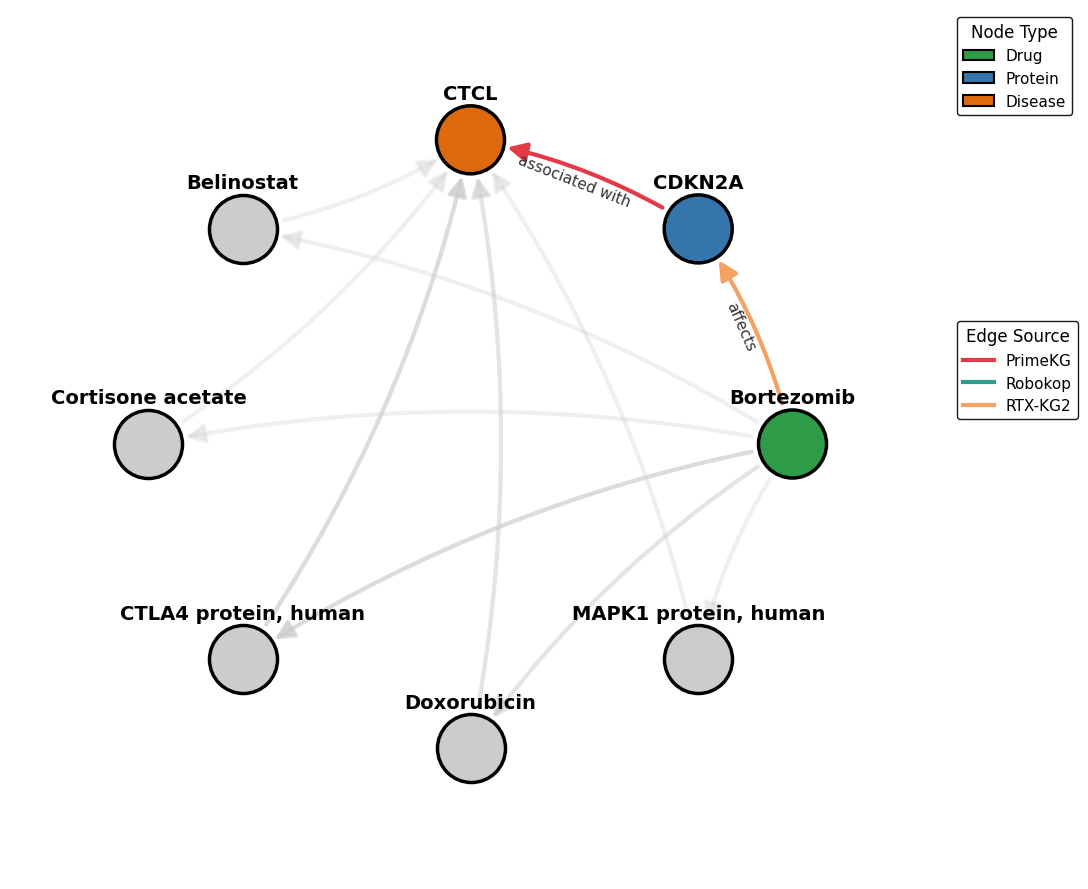

In [70]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import random

# Create a directed graph
G = nx.DiGraph()

# Define label mapping for cleaner names
label_mapping = {
    'CDKN2A protein, human': 'CDKN2A',
    'Primary cutaneous t-cell lymphoma': 'CTCL'
}

# Track which nodes are in the main path
main_path_nodes = set()

# Add nodes with labels and categories from ex_edges_df (main path)
for node_name, node_cat in set(
    list(zip(ex_edges_df['subject_name'].to_list(), ex_edges_df['subject_category'].to_list()))
    + list(zip(ex_edges_df['object_name'].to_list(), ex_edges_df['object_category'].to_list()))
):
    if not G.has_node(node_name):
        G.add_node(node_name, category=node_cat, is_main=True)
        main_path_nodes.add(node_name)

# Add main edges from ex_edges_df with source KG information
main_edges_list = []
for row in ex_edges_df.iter_rows(named=True):
    # Determine which KG(s) this edge comes from
    sources = []
    if row['is_primekg']:
        sources.append('PrimeKG')
    if row['is_robokop']:
        sources.append('Robokop')
    if row['is_rtxkg2']:
        sources.append('RTX-KG2')
    
    G.add_edge(
        row['subject_name'], row['object_name'],
        predicate=row['predicate'],
        sources=sources,
        is_main=True
    )
    main_edges_list.append((row['subject_name'], row['object_name']))

# Sample additional 2-hop paths from edges_df (Drug -> Intermediate -> Disease)
drug_nodes = [n for n in G.nodes if G.nodes[n].get('category', '').startswith('biolink:SmallMolecule') or 
              G.nodes[n].get('category', '') == 'biolink:Drug']
disease_nodes = [n for n in G.nodes if 'Disease' in G.nodes[n].get('category', '')]

# Find 2-hop paths in edges_df
additional_paths = []
random.seed(42)

# Create a lookup for edges_df by subject_name
edges_by_subject = {}
for row in edges_df.iter_rows(named=True):
    subj = row['subject_name']
    if subj not in edges_by_subject:
        edges_by_subject[subj] = []
    edges_by_subject[subj].append(row)

# Find 2-hop paths
for drug in drug_nodes:
    if drug not in edges_by_subject:
        continue
    
    drug_edges = edges_by_subject[drug]
    
    for edge1 in drug_edges[:10]:
        intermediate = edge1['object_name']
        intermediate_cat = edge1['object_category']
        
        if intermediate not in edges_by_subject:
            continue
            
        intermediate_edges = edges_by_subject[intermediate]
        for edge2 in intermediate_edges[:5]:
            if edge2['object_name'] in disease_nodes:
                path = {
                    'edge1': edge1,
                    'edge2': edge2,
                    'intermediate': intermediate,
                    'intermediate_cat': intermediate_cat
                }
                additional_paths.append(path)
                
                if not G.has_node(intermediate):
                    G.add_node(intermediate, category=intermediate_cat, is_main=False)

# Sample paths
sampled_paths = random.sample(additional_paths, min(8, len(additional_paths))) if additional_paths else []

# Add sampled paths as background edges
background_edges = []
for path in sampled_paths:
    edge1 = path['edge1']
    edge2 = path['edge2']
    
    G.add_edge(edge1['subject_name'], edge1['object_name'], 
               predicate=edge1['predicate'], sources=[], is_main=False)
    G.add_edge(edge2['subject_name'], edge2['object_name'], 
               predicate=edge2['predicate'], sources=[], is_main=False)
    
    background_edges.append((edge1['subject_name'], edge1['object_name']))
    background_edges.append((edge2['subject_name'], edge2['object_name']))

# Remove floating nodes (nodes with no edges)
nodes_to_remove = [n for n in G.nodes if G.degree(n) == 0]
G.remove_nodes_from(nodes_to_remove)

# Node color settings - GREEN for drugs, grey for background nodes
category_to_color = {
    'biolink:SmallMolecule': "#2D9B47",  # Green for drugs
    'biolink:Drug': "#2D9B47",           # Green for drugs
    'biolink:Protein': "#3475AB",        # Blue for proteins
    'biolink:Disease': "#DE6A10"         # Orange for diseases
}
grey_color = "#CCCCCC"  # Grey for background nodes

# Assign node colors based on whether they're in main path or background
node_colors = []
for n in G.nodes:
    if n in main_path_nodes:
        # Main path node - use category color
        node_colors.append(category_to_color.get(G.nodes[n].get("category", ""), "#AAAAAA"))
    else:
        # Background node - use grey
        node_colors.append(grey_color)

# Edge color settings
kg_to_color = {
    'PrimeKG': '#E63946',
    'Robokop': '#2A9D8F',
    'RTX-KG2': '#F4A261'
}

# Separate main edges (colored by source) from background edges (all grey)
main_edges = []
main_edge_colors = []

for u, v in G.edges:
    if G.edges[u, v].get('is_main', False):
        main_edges.append((u, v))
        sources = G.edges[u, v]['sources']
        if len(sources) >= 1:
            main_edge_colors.append(kg_to_color[sources[0]])
        else:
            main_edge_colors.append('#666666')

# Layout - use circular layout for more circular appearance
pos = nx.circular_layout(G)
# Alternatively, use spring layout with higher k value for more spacing
# pos = nx.spring_layout(G, seed=8, k=3.5, iterations=100)

# Begin plotting
fig, ax = plt.subplots(figsize=(12, 9))

# Draw background nodes (grey)
background_nodes = [n for n in G.nodes if n not in main_path_nodes]
if background_nodes:
    nx.draw_networkx_nodes(
        G, pos, nodelist=background_nodes,
        node_color=grey_color, node_size=2400, 
        edgecolors='k', linewidths=2.5, ax=ax
    )

# Draw main path nodes (colored by category)
if main_path_nodes:
    main_node_colors = [
        category_to_color.get(G.nodes[n].get("category", ""), "#AAAAAA")
        for n in main_path_nodes
    ]
    nx.draw_networkx_nodes(
        G, pos, nodelist=list(main_path_nodes),
        node_color=main_node_colors, node_size=2400, 
        edgecolors='k', linewidths=2.5, ax=ax
    )

# Draw ALL background edges as grey and transparent
if background_edges:
    nx.draw_networkx_edges(
        G, pos, edgelist=background_edges,
        arrows=True, 
        arrowstyle='-|>', arrowsize=28, ax=ax, width=3.0,
        edge_color='#CCCCCC',
        alpha=0.3,
        min_source_margin=30, min_target_margin=27,
        connectionstyle='arc3,rad=0.1'
    )

# Draw ONLY main path edges with their source colors (fully opaque)
if main_edges:
    nx.draw_networkx_edges(
        G, pos, edgelist=main_edges,
        arrows=True, 
        arrowstyle='-|>', arrowsize=28, ax=ax, width=3.0,
        edge_color=main_edge_colors,
        alpha=1.0,
        min_source_margin=30, min_target_margin=27,
        connectionstyle='arc3,rad=0.1'
    )

# Label positions offset from nodes
label_pos = {}
for node, (x, y) in pos.items():
    label_pos[node] = (x, y + 0.12)

# Apply label mapping
display_labels = {
    node: label_mapping.get(node, node) 
    for node in G.nodes
}

# Draw node labels WITHOUT background boxes
nx.draw_networkx_labels(
    G, label_pos, labels=display_labels,
    font_size=14, font_weight="bold", ax=ax,
    verticalalignment='bottom',
    horizontalalignment='center'
)

# Clean edge labels
def clean_predicate(pred_str):
    stripped = pred_str.replace("biolink:", "").replace("_", " ")
    if len(stripped) > 28:
        parts = stripped.split(" ")
        lines = []
        line = ""
        for p in parts:
            if len(line) + len(p) + 1 > 22:
                lines.append(line.strip())
                line = ""
            line += " " + p
        lines.append(line.strip())
        return "\n".join(lines)
    else:
        return stripped

# Only show labels for main edges
main_edge_labels = {
    (u, v): clean_predicate(G.edges[u, v]['predicate']) 
    for u, v in main_edges
}

# Draw edge labels with completely transparent background
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=main_edge_labels,
    font_color='#333333', font_size=11, ax=ax,
    label_pos=0.55,
    bbox=dict(boxstyle='round,pad=0.0', facecolor='none', edgecolor='none', alpha=0)
)

# Create legends with updated drug color
node_legend_items = [
    Patch(facecolor=category_to_color['biolink:Drug'], edgecolor='k', linewidth=1.5, label='Drug'),
    Patch(facecolor=category_to_color['biolink:Protein'], edgecolor='k', linewidth=1.5, label='Protein'),
    Patch(facecolor=category_to_color['biolink:Disease'], edgecolor='k', linewidth=1.5, label='Disease')
]

edge_legend_items = [
    Line2D([0], [0], color=kg_to_color['PrimeKG'], linewidth=3, label='PrimeKG'),
    Line2D([0], [0], color=kg_to_color['Robokop'], linewidth=3, label='Robokop'),
    Line2D([0], [0], color=kg_to_color['RTX-KG2'], linewidth=3, label='RTX-KG2')
]

node_legend = ax.legend(
    handles=node_legend_items, 
    loc='upper left', 
    bbox_to_anchor=(1.02, 1.0),
    frameon=True,
    title="Node Type",
    title_fontsize=12,
    fontsize=11,
    framealpha=0.9,
    edgecolor='black'
)

edge_legend = ax.legend(
    handles=edge_legend_items,
    loc='upper left',
    bbox_to_anchor=(1.02, 0.65),
    frameon=True,
    title="Edge Source",
    title_fontsize=12,
    fontsize=11,
    framealpha=0.9,
    edgecolor='black'
)

ax.add_artist(node_legend)

ax.margins(0.15)
plt.axis('off')
plt.tight_layout()
plt.subplots_adjust(right=0.78)
plt.show()

# Optional: Save as high-resolution figure
# plt.savefig('network_visualization.png', dpi=300, bbox_inches='tight', facecolor='white')
# plt.savefig('network_visualization.pdf', bbox_inches='tight', facecolor='white')

4-hop path

In [1]:
import json 

with open('/Users/piotrkaniewski/work/ec-kg-analysis/technical_validation/bortezomib_path.json', 'r') as f:
    data = json.load(f)



In [46]:
import polars as pl

# Create a DataFrame from paths_metadata, collecting each path's nodes, node_categories, and edge_categories into lists
df = pl.DataFrame({
    'paths': [i['nodes'] for i in data['paths_metadata']],
})

In [66]:
# To use pivot in Polars, you need to specify a column to use as values (values=...), 
# a column to use as columns (columns=...), and a column to use as rows (index=...).
# Let's assume you want to see which nodes occur at each position in each path.
# First, explode paths so each row is a node in a path with its position.
df_exploded = (
    df.with_columns(pl.row_index().alias('path_id'))
      .explode('paths')
      .with_columns(
          pl.col('paths').apply(lambda x: x).alias("node"),
          pl.col('paths').list_lengths().alias('path_length'),  # actually this gives 1, since exploded
      )
      .with_columns(
          pl.int_range(0, pl.count()).over('path_id').alias('node_idx')
      )
)

# Now, pivot so that each row is a path_id, column is node position (node_idx), value is node
pivoted = df_exploded.pivot(
    values="node", index="path_id", columns="node_idx", aggregate_function="first"
).sort("path_id")

pivoted

AttributeError: 'Expr' object has no attribute 'apply'

In [ ]:
import polars as pl
pl.DataFrame({'paths': data['translated_paths'], 'metapaths':data['paths_metadata']}, ig)

Number of translated_paths: 2102039
Number of paths_metadata: 142171


paths,metapaths
list[str],struct[3]
"[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:Disease"", … ""biolink:Disease""],[[""biolink:treats_or_applied_or_studied_to_treat""], [], [""biolink:associated_with"", ""biolink:genetically_associated_with""]]}"
"[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:Disease"", … ""biolink:Disease""],[[""biolink:treats_or_applied_or_studied_to_treat""], [], [""biolink:has_adverse_event""]]}"
"[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:Disease"", … ""biolink:Disease""],[[""biolink:treats_or_applied_or_studied_to_treat""], [], [""biolink:associated_with""]]}"
"[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:Disease"", … ""biolink:Disease""],[[""biolink:treats_or_applied_or_studied_to_treat""], [], [""biolink:treats_or_applied_or_studied_to_treat""]]}"
"[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""UMLS:C0278678"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:Disease"", … ""biolink:Disease""],[[""biolink:treats_or_applied_or_studied_to_treat""], [], [""biolink:treats""]]}"
…,…
"[""CHEBI:52717"", ""UMLS:C0079904"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""NCBIGene:30812"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:Protein"", … ""biolink:Disease""],[[], [], [""biolink:treats"", ""biolink:has_adverse_event""]]}"
"[""CHEBI:52717"", ""UMLS:C0079904"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""CHEBI:68452"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:SmallMolecule"", … ""biolink:Disease""],[[], [""biolink:interacts_with"", ""biolink:coexists_with""], [""biolink:causes""]]}"
"[""CHEBI:52717"", ""UMLS:C0079904"", … ""MONDO:0015758""]","{[""CHEBI:52717"", ""CHEBI:68452"", … ""MONDO:0015758""],[""biolink:Drug"", ""biolink:SmallMolecule"", … ""biolink:Disease""],[[], [""biolink:interacts_with""], [""biolink:has_adverse_event""]]}"


# metapath distribution


In [1]:
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Metapath counts for Bortezomib | Primary cutaneous t-cell lymphoma (4-hop, node-category signatures)
metapath_df = pl.DataFrame({
    "count": [1, 2, 13, 4, 9],
    "node_1": [
        "biolink:Drug", "biolink:Drug", "biolink:Drug", "biolink:Drug", "biolink:Drug",
    ],
    "node_2": [
        "biolink:Food", "biolink:Event", "biolink:Behavior",
        "biolink:PhysicalEntity", "biolink:ChemicalMixture",
    ],
    "node_3": ["biolink:Disease"] * 5,
}).with_columns(
    pl.concat_str([pl.col("node_1"), pl.col("node_2"), pl.col("node_3")], separator=" → ").alias("metapath"),
)

metapath_df = metapath_df.sort("count", descending=True)
metapath_df

count,node_1,node_2,node_3,metapath
i64,str,str,str,str
13,"""biolink:Drug""","""biolink:Behavior""","""biolink:Disease""","""biolink:Drug → biolink:Behavio…"
9,"""biolink:Drug""","""biolink:ChemicalMixture""","""biolink:Disease""","""biolink:Drug → biolink:Chemica…"
4,"""biolink:Drug""","""biolink:PhysicalEntity""","""biolink:Disease""","""biolink:Drug → biolink:Physica…"
2,"""biolink:Drug""","""biolink:Event""","""biolink:Disease""","""biolink:Drug → biolink:Event →…"
1,"""biolink:Drug""","""biolink:Food""","""biolink:Disease""","""biolink:Drug → biolink:Food → …"


In [3]:
def short_category(category: str) -> str:
    return category.removeprefix("biolink:").removeprefix("Biolink:")


CATEGORY_COLORS = {
    "biolink:Drug": "#2D9B47",
    "biolink:Disease": "#DE6A10",
    "biolink:Food": "#8E6C8A",
    "biolink:Event": "#6B5B95",
    "biolink:Behavior": "#C44E52",
    "biolink:PhysicalEntity": "#4C72B0",
    "biolink:ChemicalMixture": "#DD8452",
}


def build_metapath_graph(node_1: str, node_2: str, node_3: str) -> nx.DiGraph:
    """Linear 4-hop metapath as Drug → intermediate → Disease."""
    G = nx.DiGraph()
    nodes = [node_1, node_2, node_3]
    for i, category in enumerate(nodes):
        G.add_node(i, category=category, label=short_category(category))
    G.add_edge(0, 1)
    G.add_edge(1, 2)
    return G


NODE_SPACING = 0.48  # horizontal gap between nodes (compact for side-by-side figures)


def draw_metapath_row(ax_path, ax_count, row: dict) -> None:
    G = build_metapath_graph(row["node_1"], row["node_2"], row["node_3"])
    pos = {i: (i * NODE_SPACING, 0.0) for i in G.nodes}
    node_colors = [CATEGORY_COLORS.get(G.nodes[n]["category"], "#AAAAAA") for n in G.nodes]
    labels = {n: G.nodes[n]["label"] for n in G.nodes}

    nx.draw_networkx_nodes(
        G, pos, ax=ax_path, node_color=node_colors, node_size=1100,
        edgecolors="black", linewidths=1.0,
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax_path, edge_color="#555555", width=1.8,
        arrows=True, arrowsize=14, arrowstyle="-|>",
    )

    label_offset = 0.38
    label_pos = {n: (pos[n][0], pos[n][1] - label_offset) for n in G.nodes}
    nx.draw_networkx_labels(
        G, label_pos, labels=labels, ax=ax_path, font_size=8, font_weight="bold",
        verticalalignment="top", horizontalalignment="center",
    )

    x_max = (len(G.nodes) - 1) * NODE_SPACING
    ax_path.set_xlim(-0.12, x_max + 0.12)
    ax_path.set_ylim(-0.95, 0.3)
    ax_path.axis("off")

    ax_count.axis("off")
    ax_count.text(
        0.5, 0.5, str(row["count"]),
        ha="center", va="center", fontsize=12, fontweight="bold",
    )


# One row per metapath: pathway graph (LHS) + count (RHS)
rows = metapath_df.sort("count", descending=True).to_dicts()
n_rows = len(rows)

fig = plt.figure(figsize=(3.6, 1.05 * n_rows))
gs = GridSpec(n_rows, 2, figure=fig, width_ratios=[2.4, 0.35], wspace=0.02, hspace=0.02)

for i, row in enumerate(rows):
    ax_path = fig.add_subplot(gs[i, 0])
    ax_count = fig.add_subplot(gs[i, 1])
    draw_metapath_row(ax_path, ax_count, row)

fig.subplots_adjust(left=0.02, right=0.99, top=0.99, bottom=0.02)
plt.show()

fig.savefig('metapath_distribution.svg', dpi=400, bbox_inches='tight', pad_inches=0.02)

NameError: name 'nx' is not defined

# Metapath distribution for 4-hop path

In [14]:
filtered

kg,metapath,metapath_raw,count,present_in_source_kgs,is_unique_to_integrated
str,str,str,i64,str,bool
"""Integrated-KG""","""Drug → Device → OrganismTaxon …","""('biolink:Drug', 'biolink:Devi…",950,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → GrossAnatomicalStructur…","""('biolink:Drug', 'biolink:Gros…",1012,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Protein → BiologicalEnt…","""('biolink:Drug', 'biolink:Prot…",1820,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Cell → BiologicalEntity…","""('biolink:Drug', 'biolink:Cell…",730,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → ChemicalEntity → Biolog…","""('biolink:Drug', 'biolink:Chem…",645,"""Unique-to-Integrated""",true
…,…,…,…,…,…
"""Integrated-KG""","""Drug → IndividualOrganism → Ge…","""('biolink:Drug', 'biolink:Indi…",2,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → BiologicalProcess → Pat…","""('biolink:Drug', 'biolink:Biol…",1,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Food → BiologicalEntity…","""('biolink:Drug', 'biolink:Food…",1,"""Unique-to-Integrated""",true


In [16]:
metapaths.filter(
        (pl.col("present_in_source_kgs") == "Unique-to-Integrated")
        & pl.col("is_unique_to_integrated")
    )

kg,metapath,metapath_raw,count,present_in_source_kgs,is_unique_to_integrated
str,str,str,i64,str,bool
"""Integrated-KG""","""Drug → Disease → BiologicalEnt…","""('biolink:Drug', 'biolink:Dise…",9964,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Device → OrganismTaxon …","""('biolink:Drug', 'biolink:Devi…",950,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → GrossAnatomicalStructur…","""('biolink:Drug', 'biolink:Gros…",1012,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Drug → BiologicalEntity…","""('biolink:Drug', 'biolink:Drug…",9108,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Protein → BiologicalEnt…","""('biolink:Drug', 'biolink:Prot…",1820,"""Unique-to-Integrated""",true
…,…,…,…,…,…
"""Integrated-KG""","""Drug → IndividualOrganism → Ge…","""('biolink:Drug', 'biolink:Indi…",2,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → BiologicalProcess → Pat…","""('biolink:Drug', 'biolink:Biol…",1,"""Unique-to-Integrated""",true
"""Integrated-KG""","""Drug → Food → BiologicalEntity…","""('biolink:Drug', 'biolink:Food…",1,"""Unique-to-Integrated""",true


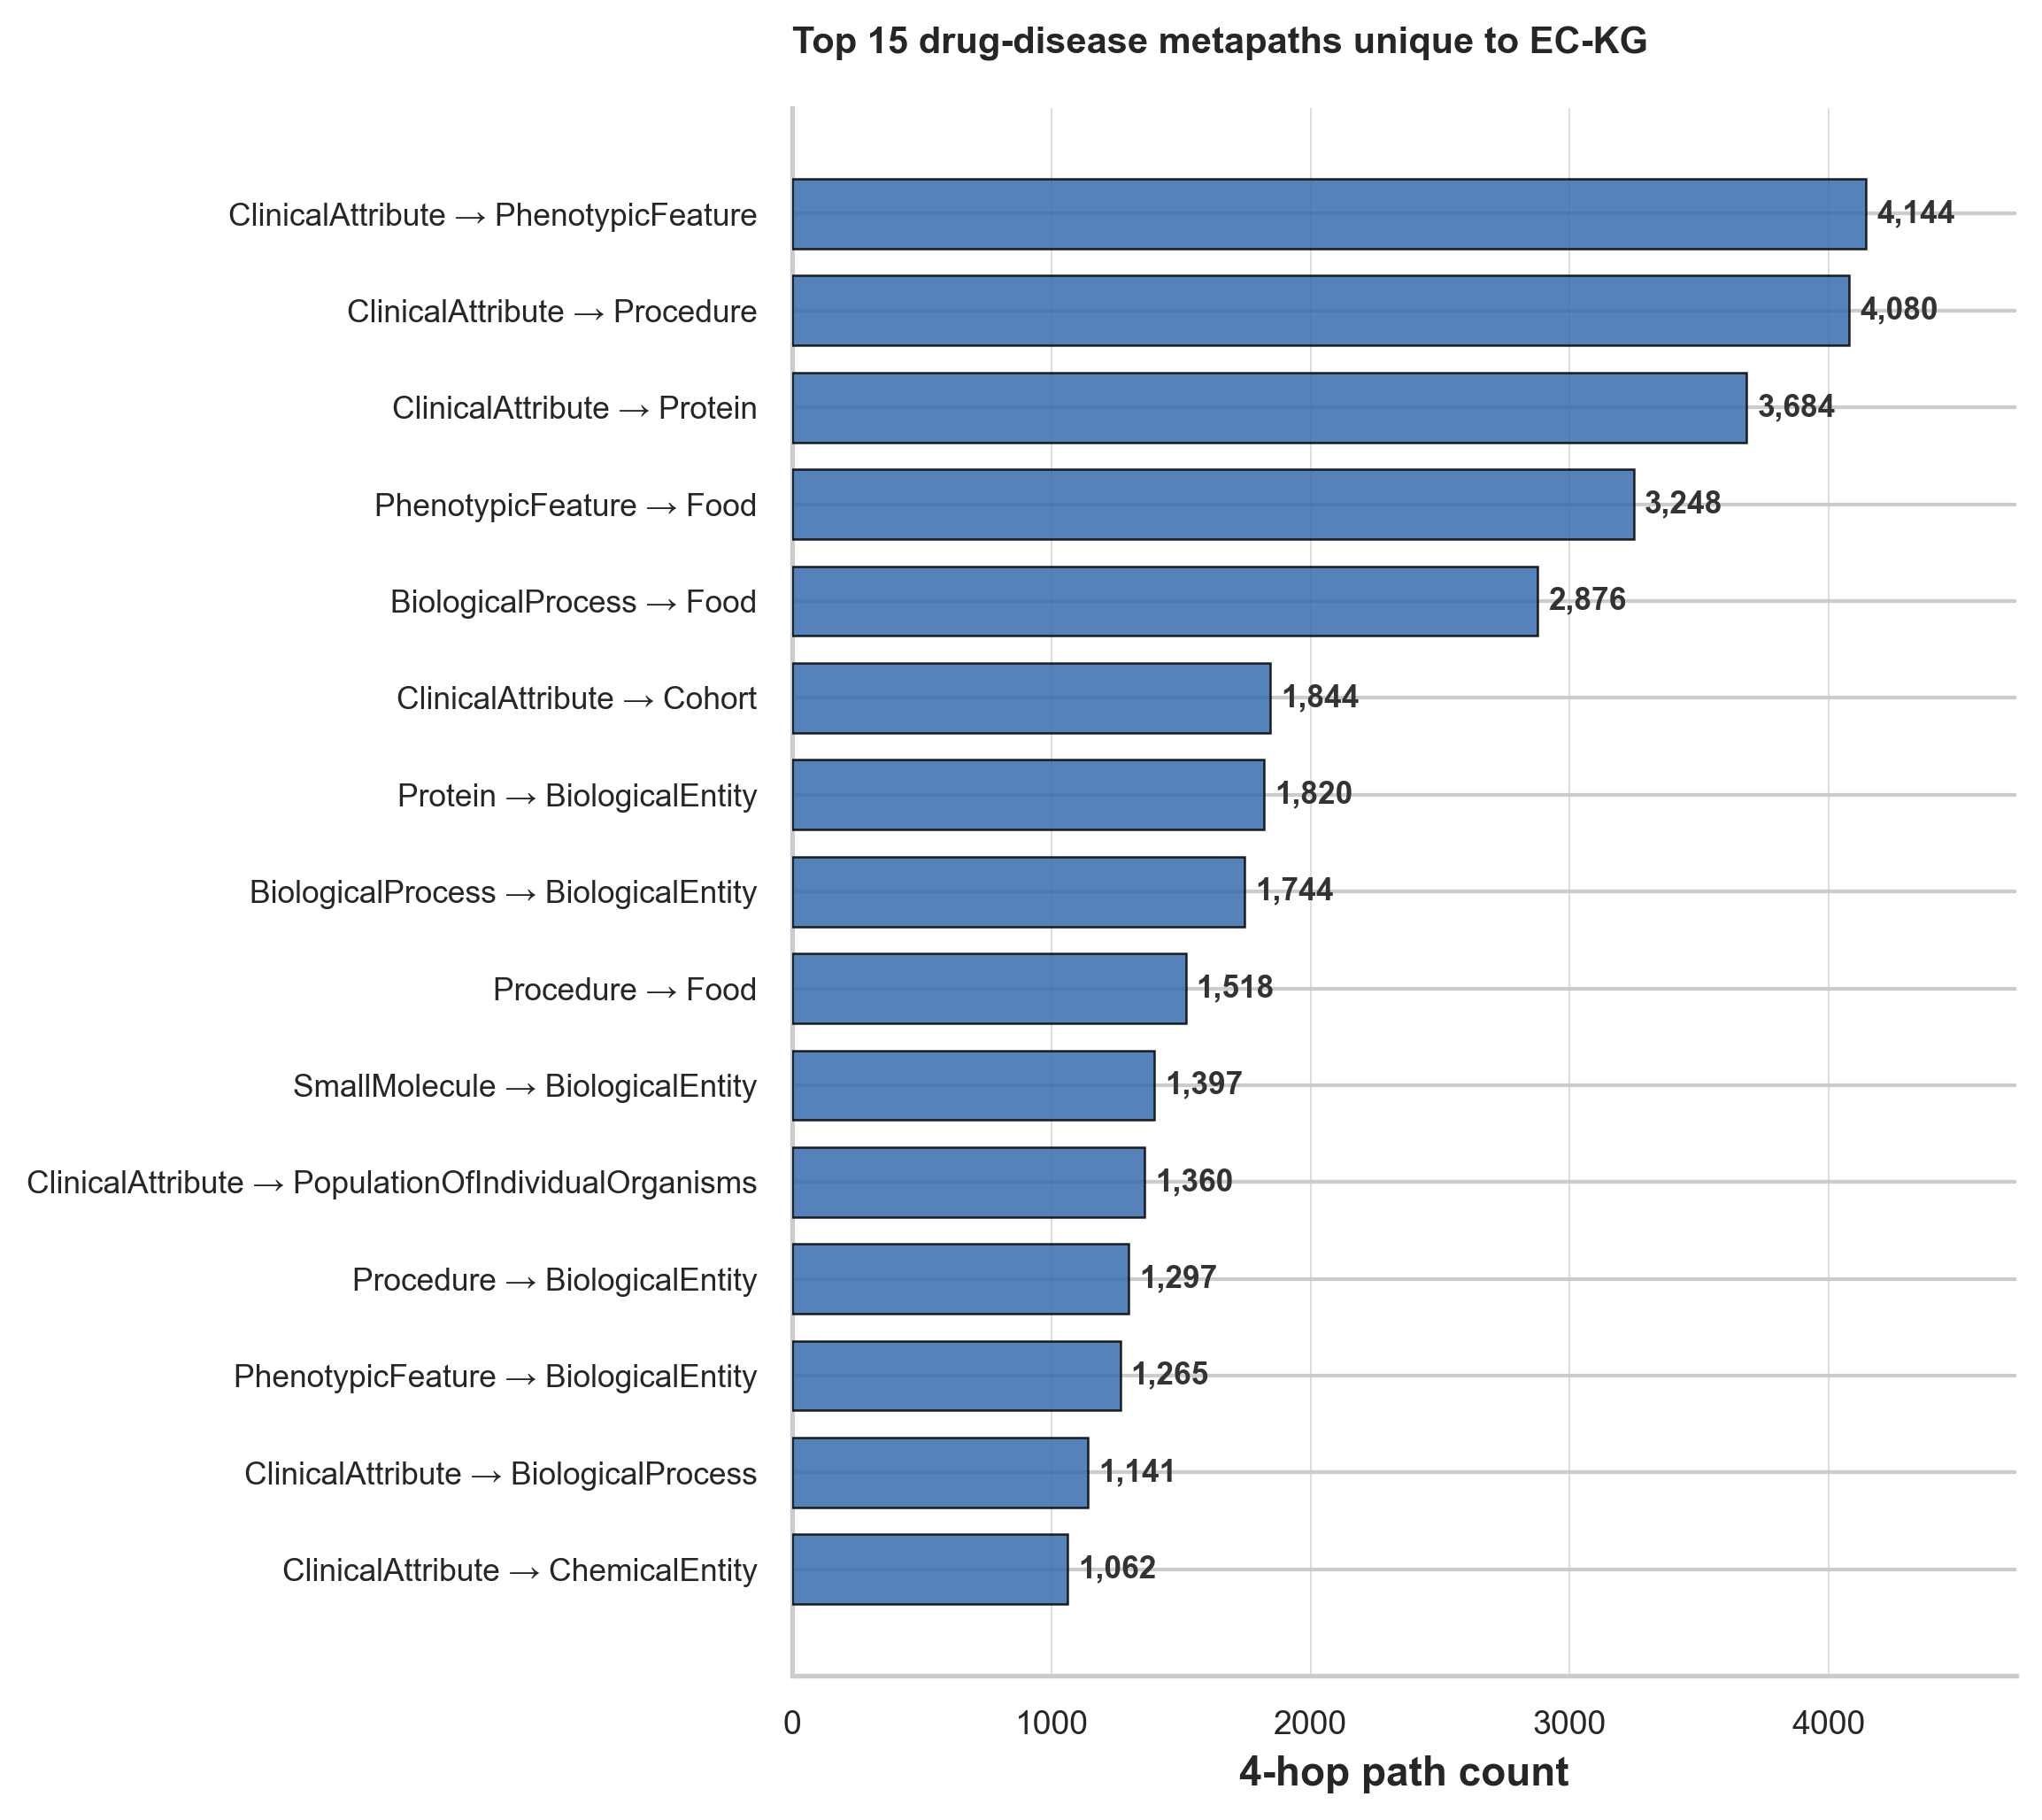

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

# EC-KG colour (05_visualize_metapath_analysis.py)
BAR_COLOR = "#386cb0"

TOP_N = 15
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / "metapath_diversity.csv").exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR / "technical_validation"
DATA_PATH = NOTEBOOK_DIR / "metapath_diversity.csv"
OUTPUT_STEM = NOTEBOOK_DIR / "unique_bio_metapath_distribution"

# Publication defaults (match metapath analysis scripts)
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 10,
    "font.family": "sans-serif",
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "xtick.labelsize": 9,
    "ytick.labelsize": 8.5,
})

metapaths = pl.read_csv(DATA_PATH)

filtered = (
    metapaths
    .filter(
        (pl.col("present_in_source_kgs") == "Unique-to-Integrated")
        & pl.col("is_unique_to_integrated")
    )
    .filter(~pl.col("metapath").str.contains("Drug → Disease"))
    .filter(~pl.col("metapath").str.contains("Drug → Drug"))
    .filter(~pl.col("metapath").str.contains("Disease → Disease"))
)

biological_keywords = [
    "Gene", "Protein", "PhenotypicFeature",
    "BiologicalProcess", "Cell", "AnatomicalEntity",
    "Pathway", "Disease", "ProteinFamily",
]
pattern = "|".join(biological_keywords)
filtered_bio = filtered.filter(pl.col("metapath").str.contains(pattern))

def trim_drug_disease_endpoints(metapath: str) -> str:
    """Drop leading Drug and trailing Disease from display labels."""
    parts = metapath.split(" → ")
    if len(parts) > 2:
        return " → ".join(parts[1:-1])
    return metapath


top_metapaths = (
    filtered_bio
    .sort("count", descending=True)
    .head(TOP_N)
)

metapath_labels = [
    trim_drug_disease_endpoints(m) for m in top_metapaths["metapath"].to_list()
]
counts = top_metapaths["count"].to_numpy()

fig_h = 0.40 * TOP_N + 1.2
fig, ax = plt.subplots(figsize=(7.2, fig_h))
fig.subplots_adjust(left=0.32, right=0.96, top=0.92, bottom=0.10)

ax.set_title(
    f"Top {TOP_N} drug-disease metapaths unique to EC-KG\n",
    loc="left",
    pad=4,
    fontsize=10,
    fontweight="bold",
)

y_pos = np.arange(len(metapath_labels))
bars = ax.barh(
    y_pos,
    counts,
    color=BAR_COLOR,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6,
    height=0.72,
    zorder=3,
)

for bar, count in zip(bars, counts):
    ax.text(
        bar.get_width() + counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        ha="left",
        fontsize=8.5,
        fontweight="bold",
        color="#333333",
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(metapath_labels)
ax.invert_yaxis()
ax.set_xlabel("4-hop path count")
ax.set_xlim(0, counts.max() * 1.14)
ax.xaxis.grid(True, linestyle="-", linewidth=0.5, color="#dddddd", zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for ext in ("svg", "png"):
    fig.savefig(
        f"{OUTPUT_STEM}.{ext}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0.04,
        facecolor="white",
    )
plt.show()